# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

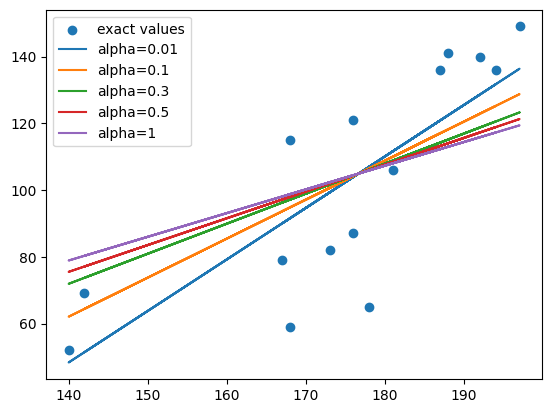

In [86]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)
x_copy = x.copy()

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.01, 0.1, 0.3, 0.5, 1]
results = []

# add 1-3 line of code here
for alpha in alphas:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w=w.ravel()
    results.append((alpha, w))
    
# add 1-3 lines to compare the results
plt.scatter(x_copy, y,label="exact values")

for alpha, w in results:
    y_predicted = np.array(w[0, 0] + w[0, 1] * x_copy)
    plt.plot(x_copy, y_predicted, label=f"alpha={alpha}")
    
plt.legend()
plt.show()   

## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [553]:
def sgd(x, y, lr = 0.01, alpha=0.1, epochs=10):
    x = np.asarray(x)
    y = np.asarray(y).flatten()
    rows, cols = x.shape
    weights = np.zeros(cols)
    
    
    x_mean = x[:, 1:].mean(axis=0)
    x_std  = x[:, 1:].std(axis=0)
    x_std[x_std == 0] = 1
    x_norm = x.copy()
    x_norm[:, 1:] = (x[:, 1:] - x_mean) / x_std
    
    for _ in range(epochs):
        for n in range(rows):
            x_n = x_norm[n]
            y_n = y[n]
        
            y_predicted = np.dot(x_n, weights)
            error = y_predicted - y_n

            grad = error * x_n
            lasso_grad = alpha * np.sign(weights)
            lasso_grad[0] = 0
            
            weights = weights - lr * (grad + lasso_grad)
                    
    bias = (weights[1:] / x_std)
    coeff = weights[0] - np.dot(bias, x_mean)
    return np.r_[coeff, bias]

In [554]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)
x_copy = x.copy()

x = np.asmatrix(np.c_[np.ones((15,1)),x])

alpha = 0.1 

w_sgd = sgd(x, y, alpha=alpha, epochs=100)
w_sgd

array([-174.66546078,    1.58381622])

In [555]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=alpha)
model.fit(x_copy, y)
model.intercept_, model.coef_

(array([-180.8579086]), array([1.61776499]))

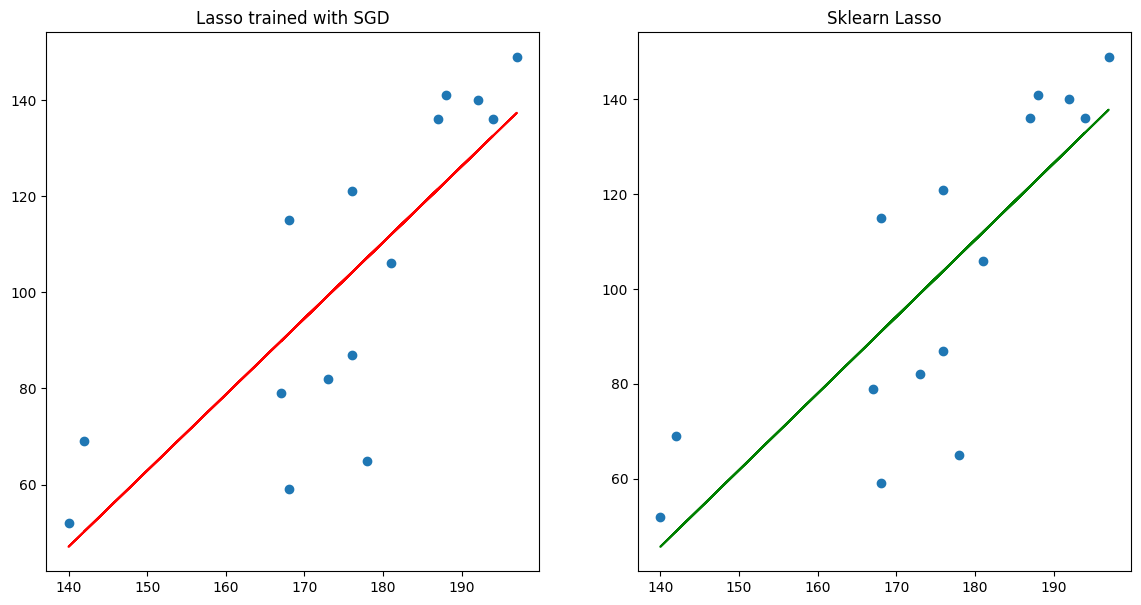

In [556]:
x = np.asarray(x)

y_pred_sgd = (np.dot(x, w_sgd)).flatten()
y_pred_sklearn = model.predict(x_copy).flatten() 

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.scatter(x_copy.flatten(), y.flatten())
plt.plot(x_copy.flatten(), y_pred_sgd, color='r')
plt.title("Lasso trained with SGD")

plt.subplot(1, 2, 2)
plt.scatter(x_copy.flatten(), y.flatten())
plt.plot(x_copy.flatten(), y_pred_sklearn, color='g')
plt.title("Sklearn Lasso")

plt.show()

## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

In [601]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [599]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
iris_df['target'] = iris_data.target  
iris_df.head()

x = iris_df[['sepal width (cm)', 'petal length (cm)']].values # change here
y = iris_df['target'].values.reshape(-1,1) # change here

dataset_size = np.size(x)

mean_x, mean_y = np.mean(x), np.mean(y)

SS_xy = np.sum(y * x) - dataset_size * mean_y * mean_x
SS_xx = np.sum(x * x) - dataset_size * mean_x * mean_x

a = SS_xy / SS_xx
b = mean_y - a * mean_x


y_pred = a * x + b